# Fine-tuning PIDNet for Fire and Smoke Detection

This notebook fine-tunes **PIDNet** (Official repository integration) on a custom fire and smoke segmentation dataset using PyTorch Lightning.

## Dataset Format
- Images: RGB images
- Labels: YOLO-style segmentation format (normalized polygon coordinates)

## Performance Optimizations
- Optimized image size (512x1024)
- Increased data loading workers (8)
- Simplified augmentations for speed
- Persistent workers and prefetch enabled
- cuDNN benchmarking enabled

## 1. Install Required Packages

In [1]:
%pip install pytorch-lightning pillow numpy opencv-python matplotlib torch torchvision albumentations scikit-learn seaborn yacs pyyaml easydict

import os
import sys
import subprocess

PIDNET_REPO = 'PIDNet'
if not os.path.isdir(PIDNET_REPO):
    subprocess.run(['git', 'clone', 'https://github.com/XuJiacong/PIDNet.git', PIDNET_REPO], check=True)

# Editable install (safe to ignore if repository does not expose a package)
subprocess.run([sys.executable, '-m', 'pip', 'install', '-e', PIDNET_REPO], check=False)


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Obtaining file:///mnt/c/Users/PC/Documents/Researchfr/PIDNet/PIDNet



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip
ERROR: file:///mnt/c/Users/PC/Documents/Researchfr/PIDNet/PIDNet does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.


CompletedProcess(args=['/home/maks/miniconda3/envs/AIEnv/bin/python', '-m', 'pip', 'install', '-e', 'PIDNet'], returncode=1)

In [1]:
import os
import sys
import subprocess

## 2. Import Libraries

In [1]:
import os
import sys
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import List, Tuple, Dict, Optional, Union

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import albumentations as A

import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import TensorBoardLogger

from sklearn.metrics import confusion_matrix

PIDNET_REPO_PATH = Path('PIDNet').resolve()
if str(PIDNET_REPO_PATH) not in sys.path:
    sys.path.insert(0, str(PIDNET_REPO_PATH))


print(f'PyTorch version: {torch.__version__}')
print(f'PyTorch Lightning version: {pl.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
print(f'PIDNet repo path: {PIDNET_REPO_PATH}')

# Set global seed for reproducibility
pl.seed_everything(42, workers=True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


Seed set to 42


PyTorch version: 2.9.0+cu130
PyTorch Lightning version: 2.6.1
CUDA available: True
PIDNet repo path: /mnt/c/Users/PC/Documents/Researchfr/PIDNet/PIDNet


## 3. Configuration

In [19]:
# Paths
DATA_ROOT = 'pruned_dataset_safe'
IMAGES_DIR = os.path.join(DATA_ROOT, 'images')
LABELS_DIR = os.path.join(DATA_ROOT, 'labels')

# PIDNet model configuration
MODEL_NAME = 'pidnet-m'  # Options: pidnet-s, pidnet-m, pidnet-l
PRETRAINED_WEIGHTS = 'PIDNet/pretrained_models/imagenet/PIDNet_M_ImageNet.pth.tar'
NUM_CLASSES = 3  # Background, Fire, Smoke
IMAGE_SIZE = (1024, 1024)  # (height, width)
USE_AUX_LOSS = False
AUX_LOSS_WEIGHT = 0.4

# Optional sanity check for the pretrained checkpoint path
if PRETRAINED_WEIGHTS is not None and not os.path.isfile(PRETRAINED_WEIGHTS):
    print(f'Warning: pretrained checkpoint not found at {PRETRAINED_WEIGHTS}')

# Training configuration
BATCH_SIZE = 10
NUM_WORKERS = 8
MAX_EPOCHS = 150
LEARNING_RATE = 6e-5
TRAIN_SPLIT = 0.8
VAL_SPLIT = 0.1
TEST_SPLIT = 0.1

# Balanced SAHI-style tiling (train/val/test)
ENABLE_BALANCED_TILING = True
TILE_SIZE = IMAGE_SIZE  # (height, width)
TILE_OVERLAP = 0.5
NEG_POS_TILE_RATIO = 0.1  # small fraction of background tiles keeps model from over-predicting fire/smoke
MIN_FG_PIXELS = 64  # Minimum fire/smoke pixels for a tile to count as positive
TILING_RANDOM_SEED = 42

# Exhaustive (full-coverage, non-overlapping) tiling for val and test.
# overlap=0.0 means each pixel appears in exactly one tile, so
# accumulated per-tile IoU equals true full-image IoU.
ENABLE_VAL_TILING = True
ENABLE_TEST_TILING = True
VAL_TEST_TILE_OVERLAP = 0.0   # Must be 0 for pixel-exact IoU accumulation

# Cached splits/tiles
USE_SPLITS_JSON = True
SPLITS_JSON_PATH = 'data_splits_and_tilingproper.json'

# RGCr channel mode
USE_RGCR = False
RGCR_MEAN = [0.485, 0.456, 0.5]  # [R, G, Cr]
RGCR_STD = [0.229, 0.224, 0.25]

# Class names
CLASS_NAMES = ['background', 'fire', 'smoke']
ID2LABEL = {i: label for i, label in enumerate(CLASS_NAMES)}
LABEL2ID = {label: i for i, label in enumerate(CLASS_NAMES)}
# Class weights for handling imbalance (Fire:Smoke = 1:7)
CLASS_WEIGHTS = torch.tensor([0.3, 3.0, 1.0])  # [background, fire, smoke] -- reduced: 10x fire weight across 3 losses caused oscillation

# Loss configuration
LOVASZ_WEIGHT = 0.33
FOCAL_WEIGHT = 0.33
DICE_WEIGHT = 0.34
FOCAL_GAMMA = 2.0


### Class Imbalance Handling Strategy

The dataset has a severe class imbalance with Fire:Smoke ratio of 1:7. To address this:

1. **Class Weights**: Fire class receives 7x weight compared to smoke
2. **Combined Loss Function**:
   - **Lovasz-Softmax Loss (50%)**: Directly optimizes IoU-style set overlap, which is well-suited for class-imbalanced segmentation
   - **Focal Loss (50%)**: Down-weights easy examples and focuses on hard examples, with gamma=2.0
3. **Per-class IoU Monitoring**: Track IoU for each class separately to ensure the underrepresented fire class is learned properly

## 4. YOLO to Segmentation Mask Conversion

In [3]:
def yolo_to_mask(label_path: str, img_height: int, img_width: int, num_classes: int) -> np.ndarray:
    """Convert YOLO segmentation annotations into a semantic mask."""
    mask = np.zeros((img_height, img_width), dtype=np.uint8)

    if not os.path.exists(label_path):
        return mask

    with open(label_path, 'r') as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()
        if len(parts) < 3:
            continue

        class_id = int(parts[0]) + 1  # +1 because 0 is background
        class_id = max(0, min(class_id, num_classes - 1))
        coords = list(map(float, parts[1:]))

        points = []
        for i in range(0, len(coords), 2):
            x = int(coords[i] * img_width)
            y = int(coords[i + 1] * img_height)
            points.append([x, y])

        if len(points) >= 3:
            points = np.array(points, dtype=np.int32)
            cv2.fillPoly(mask, [points], class_id)

    return mask


def _compute_tile_starts(length: int, tile_length: int, stride: int) -> List[int]:
    """Return valid start indices with guaranteed edge coverage."""
    if length <= tile_length:
        return [0]

    starts = list(range(0, max(1, length - tile_length + 1), stride))
    last_start = length - tile_length
    if starts[-1] != last_start:
        starts.append(last_start)
    return starts


def generate_tile_boxes(img_height: int, img_width: int, tile_size: Tuple[int, int], overlap: float) -> List[Tuple[int, int, int, int]]:
    """Generate sliding-window tile boxes as (x0, y0, x1, y1)."""
    tile_h, tile_w = tile_size
    tile_h = min(tile_h, img_height)
    tile_w = min(tile_w, img_width)

    stride_h = max(1, int(tile_h * (1.0 - overlap)))
    stride_w = max(1, int(tile_w * (1.0 - overlap)))

    y_starts = _compute_tile_starts(img_height, tile_h, stride_h)
    x_starts = _compute_tile_starts(img_width, tile_w, stride_w)

    boxes = []
    for y0 in y_starts:
        for x0 in x_starts:
            x1 = x0 + tile_w
            y1 = y0 + tile_h
            boxes.append((x0, y0, x1, y1))

    return boxes


def build_balanced_tile_index(
    images_dir: str,
    labels_dir: str,
    image_files: List[str],
    num_classes: int,
    tile_size: Tuple[int, int],
    overlap: float,
    min_fg_pixels: int = 16,
    neg_pos_ratio: float = 1.0,
    seed: int = 42,
) -> Tuple[List[Tuple[str, int, int, int, int]], Dict[str, int]]:
    """Keep positive tiles and optionally sample negatives based on the ratio."""
    rng = np.random.default_rng(seed)

    positives: List[Tuple[str, int, int, int, int]] = []
    negatives: List[Tuple[str, int, int, int, int]] = []
    foreground_ids = list(range(1, num_classes))

    for img_name in image_files:
        img_path = os.path.join(images_dir, img_name)
        if not os.path.isfile(img_path):
            continue

        with Image.open(img_path) as img:
            img = img.convert('RGB')
            image_np = np.array(img)

        img_h, img_w = image_np.shape[:2]
        label_name = os.path.splitext(img_name)[0] + '.txt'
        label_path = os.path.join(labels_dir, label_name)
        mask = yolo_to_mask(label_path, img_h, img_w, num_classes)

        for x0, y0, x1, y1 in generate_tile_boxes(img_h, img_w, tile_size, overlap):
            tile_mask = mask[y0:y1, x0:x1]
            fg_pixels = int(np.count_nonzero(np.isin(tile_mask, foreground_ids)))
            if fg_pixels >= min_fg_pixels:
                positives.append((img_name, x0, y0, x1, y1))
            elif neg_pos_ratio > 0:
                negatives.append((img_name, x0, y0, x1, y1))

    sampled_negatives = negatives
    if positives:
        max_negatives = int(np.ceil(len(positives) * max(0.0, neg_pos_ratio)))
        if max_negatives <= 0:
            sampled_negatives = []
        elif len(negatives) > max_negatives:
            selected_idx = rng.choice(len(negatives), size=max_negatives, replace=False)
            sampled_negatives = [negatives[i] for i in selected_idx]
    elif negatives:
        max_keep = max(1, min(len(negatives), len(image_files)))
        if len(negatives) > max_keep:
            selected_idx = rng.choice(len(negatives), size=max_keep, replace=False)
            sampled_negatives = [negatives[i] for i in selected_idx]

    tile_records = positives + sampled_negatives
    if tile_records:
        order = rng.permutation(len(tile_records))
        tile_records = [tile_records[i] for i in order]

    stats = {
        'positive_tiles': len(positives),
        'negative_tiles_before_sampling': len(negatives),
        'negative_tiles_after_sampling': len(sampled_negatives),
        'total_tiles': len(tile_records),
    }    
    return tile_records, stats


def build_exhaustive_tile_index(
    images_dir: str,
    labels_dir: str,
    image_files: List[str],
    tile_size: Tuple[int, int],
    overlap: float = 0.0,
) -> List[Tuple[str, int, int, int, int]]:
    """Return tiles that cover every pixel of every image exactly once.

    Unlike build_balanced_tile_index, no content-based filtering is applied:
    all tiles (positive and background) are included. With overlap=0.0
    each pixel appears in exactly one tile, so accumulating intersection/union
    across tiles yields the same IoU as computing over the full original image.
    """
    tile_records: List[Tuple[str, int, int, int, int]] = []

    for img_name in image_files:
        img_path = os.path.join(images_dir, img_name)
        if not os.path.isfile(img_path):
            continue
        with Image.open(img_path) as img:
            img_w, img_h = img.size  # PIL gives (width, height)

        for x0, y0, x1, y1 in generate_tile_boxes(img_h, img_w, tile_size, overlap):
            tile_records.append((img_name, x0, y0, x1, y1))

    return tile_records

## 5. Custom Dataset Class

### Data Augmentation Strategy

To improve model generalization while maintaining fast training speed, the following **lightweight** augmentations are applied **only during training**:

**Geometric Transformations:**
- Horizontal flip (50% probability)
- Random 90 degree rotation (50% probability)
- Minimal shift/scale/rotation (30% probability, reduced range)

**Color Augmentation:**
- Random brightness and contrast adjustment (40% probability)

**Blur:**
- Light Gaussian blur (15% probability) - simulates motion/smoke blur

**Performance Notes:**
- Augmentations simplified for faster data loading
- All augmentations preserve spatial correspondence between image and mask
- PIDNet preprocessing performs resize + normalization after augmentation

### Extra Strategies for Small Smoke/Fire Objects

In addition to balanced tiling, RGCr channels, and Dice-mixed loss, you can improve tiny-object recall with:

1. **Hard pixel mining (OHEM)**: prioritize hardest fire/smoke pixels in each batch.
2. **Scale jitter focused on upscaling**: bias random scales above 1.0 so tiny objects occupy more pixels.
3. **Copy-paste fire/smoke regions**: paste small foreground snippets onto hard backgrounds to increase rare positives.
4. **Boundary-aware supervision**: increase edge loss weight to preserve thin smoke structures.
5. **Test-time augmentation (TTA)**: average predictions across flips/scales at evaluation.
6. **Temporal ensembling (if video)**: smooth logits over nearby frames to stabilize tiny smoke detections.
7. **Post-processing for tiny blobs**: keep connected components that are small but high-confidence instead of removing all small regions.

## 6A. Custom Loss Functions for Class Imbalance

Implementing a combined **Lovasz-Softmax + Focal + Dice** loss to handle severe class imbalance and improve small fire/smoke object segmentation.

In [4]:
class LovaszSoftmaxLoss(nn.Module):
    def __init__(self, classes='present', per_image=False, ignore_index=None, class_weights=None):
        super().__init__()
        self.classes = classes
        self.per_image = per_image
        self.ignore_index = ignore_index
        self.class_weights = class_weights

    @staticmethod
    def _lovasz_grad(gt_sorted):
        gts = gt_sorted.sum()
        p = len(gt_sorted)
        intersection = gts - gt_sorted.cumsum(0)
        union = gts + (1.0 - gt_sorted).cumsum(0)
        jaccard = 1.0 - intersection / union
        if p > 1:
            jaccard[1:p] = jaccard[1:p] - jaccard[0:-1]
        return jaccard

    def _flatten_probas(self, probas, labels):
        if probas.dim() != 4:
            raise ValueError(f'Expected probas as [B, C, H, W], got shape {probas.shape}')

        c = probas.size(1)
        probas = probas.permute(0, 2, 3, 1).contiguous().view(-1, c)
        labels = labels.view(-1)

        if self.ignore_index is None:
            return probas, labels

        valid = labels != self.ignore_index
        return probas[valid], labels[valid]

    def _lovasz_softmax_flat(self, probas, labels):
        if probas.numel() == 0:
            return probas.sum() * 0.0

        num_classes = probas.size(1)
        losses = []

        for cls in range(num_classes):
            fg = (labels == cls).float()
            if self.classes == 'present' and fg.sum() == 0:
                continue

            errors = (fg - probas[:, cls]).abs()
            errors_sorted, perm = torch.sort(errors, descending=True)
            fg_sorted = fg[perm]
            loss_cls = torch.dot(errors_sorted, self._lovasz_grad(fg_sorted))

            if self.class_weights is not None:
                weights = self.class_weights.to(probas.device)
                loss_cls = loss_cls * weights[cls]

            losses.append(loss_cls)

        if not losses:
            return probas.sum() * 0.0
        return torch.stack(losses).mean()

    def forward(self, logits, labels):
        probas = torch.softmax(logits, dim=1)

        if self.per_image:
            losses = []
            for p, l in zip(probas, labels):
                p = p.unsqueeze(0)
                l = l.unsqueeze(0)
                flat_p, flat_l = self._flatten_probas(p, l)
                losses.append(self._lovasz_softmax_flat(flat_p, flat_l))
            return torch.stack(losses).mean() if losses else logits.sum() * 0.0

        flat_probas, flat_labels = self._flatten_probas(probas, labels)
        return self._lovasz_softmax_flat(flat_probas, flat_labels)


class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean', ignore_index=-100):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.ignore_index = ignore_index

    def forward(self, logits, targets):
        _, c, _, _ = logits.shape
        logits = logits.permute(0, 2, 3, 1).contiguous().view(-1, c)
        targets = targets.view(-1)

        ce_loss = nn.functional.cross_entropy(logits, targets, reduction='none', ignore_index=self.ignore_index)

        probs = torch.softmax(logits, dim=1)
        safe_targets = targets.clone()
        safe_targets[safe_targets == self.ignore_index] = 0
        pt = probs.gather(1, safe_targets.unsqueeze(1)).squeeze(1)
        focal_weight = (1.0 - pt) ** self.gamma
        focal_loss = focal_weight * ce_loss

        if self.alpha is not None:
            alpha_weights = self.alpha.to(logits.device)
            alpha_t = alpha_weights.gather(0, safe_targets)
            focal_loss = alpha_t * focal_loss

        if self.reduction == 'mean':
            valid_mask = targets != self.ignore_index
            if valid_mask.any():
                return focal_loss[valid_mask].mean()
            return focal_loss.mean()
        if self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss


class DiceLoss(nn.Module):
    def __init__(self, class_weights=None, smooth: float = 1.0, ignore_index: int = -100, include_background: bool = False):
        super().__init__()
        self.class_weights = class_weights
        self.smooth = smooth
        self.ignore_index = ignore_index
        self.include_background = include_background

    def forward(self, logits, targets):
        probs = torch.softmax(logits, dim=1)
        targets = targets.long()

        valid_mask = torch.ones_like(targets, dtype=torch.bool)
        if self.ignore_index is not None:
            valid_mask = targets != self.ignore_index

        safe_targets = targets.clone()
        safe_targets[~valid_mask] = 0

        one_hot = torch.zeros_like(probs).scatter_(1, safe_targets.unsqueeze(1), 1.0)
        valid_mask_f = valid_mask.unsqueeze(1).float()

        probs = probs * valid_mask_f
        one_hot = one_hot * valid_mask_f

        dims = (0, 2, 3)
        intersection = (probs * one_hot).sum(dim=dims)
        denominator = (probs + one_hot).sum(dim=dims)

        dice_score = (2.0 * intersection + self.smooth) / (denominator + self.smooth)
        dice_loss = 1.0 - dice_score

        if not self.include_background and dice_loss.numel() > 1:
            dice_loss = dice_loss[1:]

        if self.class_weights is not None:
            weights = self.class_weights.to(logits.device).float()
            if not self.include_background and weights.numel() > 1:
                weights = weights[1:]
            weights = weights / (weights.sum() + 1e-12)
            return (dice_loss * weights).sum()

        return dice_loss.mean()


class CombinedLoss(nn.Module):
    def __init__(self, num_classes, lovasz_weight=0.33, focal_weight=0.33, dice_weight=0.34, class_weights=None, focal_gamma=2.0, ignore_index=-100):
        super().__init__()
        self.lovasz_weight = lovasz_weight
        self.focal_weight = focal_weight
        self.dice_weight = dice_weight
        self.lovasz_loss = LovaszSoftmaxLoss(class_weights=class_weights, ignore_index=ignore_index)
        self.focal_loss = FocalLoss(alpha=class_weights, gamma=focal_gamma, ignore_index=ignore_index)
        self.dice_loss = DiceLoss(class_weights=class_weights, ignore_index=ignore_index, include_background=False)

    def forward(self, logits, targets):
        lovasz = self.lovasz_loss(logits, targets)
        focal = self.focal_loss(logits, targets)
        dice = self.dice_loss(logits, targets)

        total_weight = self.lovasz_weight + self.focal_weight + self.dice_weight
        if total_weight <= 0:
            raise ValueError('Total loss weight must be positive.')

        combined = (
            self.lovasz_weight * lovasz
            + self.focal_weight * focal
            + self.dice_weight * dice
        ) / total_weight
        return combined, lovasz, focal, dice

In [5]:
class PIDNetPreprocessor:
    def __init__(self, size=(512, 1024), use_rgcr: bool = False, mean: Optional[List[float]] = None, std: Optional[List[float]] = None):
        self.size = size
        self.use_rgcr = use_rgcr

        if mean is None:
            mean = [0.485, 0.456, 0.5] if self.use_rgcr else [0.485, 0.456, 0.406]
        if std is None:
            std = [0.229, 0.224, 0.25] if self.use_rgcr else [0.229, 0.224, 0.225]

        self.mean = np.array(mean, dtype=np.float32)
        self.std = np.array(std, dtype=np.float32)

    @staticmethod
    def _to_rgcr(image_np: np.ndarray) -> np.ndarray:
        """Convert RGB image into RGCr channels (R, G, Cr from YCrCb)."""
        ycrcb = cv2.cvtColor(image_np, cv2.COLOR_RGB2YCrCb)
        cr = ycrcb[:, :, 1]
        rgcr = np.stack([image_np[:, :, 0], image_np[:, :, 1], cr], axis=-1)
        return rgcr

    def __call__(self, image_np: np.ndarray, mask_np: np.ndarray) -> Dict[str, torch.Tensor]:
        h, w = self.size
        image_resized = cv2.resize(image_np, (w, h), interpolation=cv2.INTER_LINEAR)
        mask_resized = cv2.resize(mask_np, (w, h), interpolation=cv2.INTER_NEAREST)

        if self.use_rgcr:
            image_resized = self._to_rgcr(image_resized)

        image_float = image_resized.astype(np.float32) / 255.0
        image_float = (image_float - self.mean) / self.std

        pixel_values = torch.from_numpy(image_float.transpose(2, 0, 1)).float()
        labels = torch.from_numpy(mask_resized).long()
        return {'pixel_values': pixel_values, 'labels': labels}

class FireSmokeDataset(Dataset):
    def __init__(
        self,
        images_dir: str,
        labels_dir: str,
        image_files: List[str],
        preprocessor,
        num_classes: int = 3,
        augment: bool = False,
        use_tiling: bool = False,
        tile_records: Optional[List[Tuple[str, int, int, int, int]]] = None,
        focus_on_object: bool = False,
        object_crop_padding: float = 0.25,
        object_crop_min_pixels: int = 16,
    ):
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.image_files = image_files
        self.preprocessor = preprocessor
        self.num_classes = num_classes
        self.augment = augment
        self.tile_records = tile_records if tile_records is not None else []
        self.focus_on_object = focus_on_object
        self.object_crop_padding = object_crop_padding
        self.object_crop_min_pixels = object_crop_min_pixels
        self.use_tiling = use_tiling and len(self.tile_records) > 0

        if self.augment:
                        self.transform = A.Compose([
                A.HorizontalFlip(p=0.5),
                A.RandomRotate90(p=0.5),
                A.ShiftScaleRotate(
                    shift_limit=0.1,
                    scale_limit=0.3,
                    rotate_limit=15,
                    border_mode=cv2.BORDER_CONSTANT,
                    p=0.5),
                A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
                A.GaussianBlur(blur_limit=(3, 5), p=0.15),
                A.CoarseDropout(max_holes=8, max_height=64, max_width=64, min_holes=1, min_height=8, min_width=8, fill_value=0, mask_fill_value=0, p=0.3),
            ])
        else:
            self.transform = None

    def __len__(self):
        if self.use_tiling:
            return len(self.tile_records)
        return len(self.image_files)

    def __getitem__(self, idx):
        if self.use_tiling:
            img_name, x0, y0, x1, y1 = self.tile_records[idx]
        else:
            img_name = self.image_files[idx]
            x0 = y0 = x1 = y1 = None

        img_path = os.path.join(self.images_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        image_np = np.array(image)

        label_name = os.path.splitext(img_name)[0] + '.txt'
        label_path = os.path.join(self.labels_dir, label_name)
        mask = yolo_to_mask(label_path, image_np.shape[0], image_np.shape[1], self.num_classes)

        if self.transform is not None:
            transformed = self.transform(image=image_np, mask=mask)
            image_np = transformed['image']
            mask = transformed['mask']
        h, w = image_np.shape[:2]
        if self.use_tiling:
            x0 = max(0, min(int(x0), max(w - 1, 0)))
            y0 = max(0, min(int(y0), max(h - 1, 0)))
            x1 = max(x0 + 1, min(int(x1), w))
            y1 = max(y0 + 1, min(int(y1), h))
            image_np = image_np[y0:y1, x0:x1]
            mask = mask[y0:y1, x0:x1]

        encoded = self.preprocessor(image_np, mask)
        encoded['image_name'] = img_name
        encoded['crop_box'] = torch.tensor([x0, y0, x1, y1] if self.use_tiling else [-1, -1, -1, -1])
        encoded['orig_shape'] = torch.tensor([h, w])
        return encoded


## 6. PyTorch Lightning DataModule

In [6]:
class FireSmokeDataModule(pl.LightningDataModule):
    def __init__(
        self,
        images_dir: str,
        labels_dir: str,
        preprocessor,
        batch_size: int = 4,
        num_workers: int = 4,
        train_split: float = 0.8,
        val_split: float = 0.1,
        num_classes: int = 3,
        enable_balanced_tiling: bool = False,
        tile_size: Tuple[int, int] = (512, 1024),
        tile_overlap: float = 0.5,
        neg_pos_tile_ratio: float = 1.0,
        min_fg_pixels: int = 16,
        tiling_seed: int = 42,
        enable_object_crop: bool = False,
        object_crop_padding: float = 0.25,
        object_crop_min_pixels: int = 16,
        splits_json_path: str = 'data_splits_and_tiling.json',
        enable_val_tiling: bool = False,
        enable_test_tiling: bool = False,
        val_test_tile_overlap: float = 0.0,
    ):
        super().__init__()
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.preprocessor = preprocessor
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.train_split = train_split
        self.val_split = val_split
        self.num_classes = num_classes

        self.enable_balanced_tiling = enable_balanced_tiling
        self.tile_size = tile_size
        self.tile_overlap = tile_overlap
        self.neg_pos_tile_ratio = neg_pos_tile_ratio
        self.min_fg_pixels = min_fg_pixels
        self.tiling_seed = tiling_seed
        self.tile_stats = None
        self.val_tile_stats = None
        self.test_tile_stats = None
        self.enable_object_crop = enable_object_crop
        self.object_crop_padding = object_crop_padding
        self.object_crop_min_pixels = object_crop_min_pixels
        self.splits_json_path = splits_json_path
        self.enable_val_tiling = enable_val_tiling
        self.enable_test_tiling = enable_test_tiling
        self.val_test_tile_overlap = val_test_tile_overlap

    def _load_splits_from_json(self) -> Optional[Dict[str, object]]:
        if not self.splits_json_path:
            return None
        if not os.path.isfile(self.splits_json_path):
            return None
        try:
            import json
            with open(self.splits_json_path, 'r') as f:
                data = json.load(f)
            return data
        except Exception as exc:
            print(f'Warning: failed to load {self.splits_json_path}: {exc}')
            return None

    def _expected_tile_config(self) -> Dict[str, object]:
        return {
            'enable_balanced_tiling': self.enable_balanced_tiling,
            'tile_size': list(self.tile_size),
            'tile_overlap': self.tile_overlap,
            'min_fg_pixels': self.min_fg_pixels,
            'neg_pos_tile_ratio': self.neg_pos_tile_ratio,
            'image_size': list(self.preprocessor.size),
        }
    def _build_exhaustive_tiles(self, image_files: List[str]) -> List[Tuple[str, int, int, int, int]]:
        """Build full-coverage non-overlapping tiles for val/test evaluation."""
        return build_exhaustive_tile_index(
            images_dir=self.images_dir,
            labels_dir=self.labels_dir,
            image_files=image_files,
            tile_size=self.tile_size,
            overlap=self.val_test_tile_overlap,
        )

    def _build_split_tiles(self, image_files: List[str]):
        return build_balanced_tile_index(
            images_dir=self.images_dir,
            labels_dir=self.labels_dir,
            image_files=image_files,
            num_classes=self.num_classes,
            tile_size=self.tile_size,
            overlap=self.tile_overlap,
            min_fg_pixels=self.min_fg_pixels,
            neg_pos_ratio=self.neg_pos_tile_ratio,
            seed=self.tiling_seed,
        )

    def setup(self, stage=None):
        if self.enable_balanced_tiling and self.enable_object_crop:
            raise ValueError('enable_balanced_tiling and enable_object_crop are mutually exclusive.')

        loaded = self._load_splits_from_json()
        if loaded:
            train_images = loaded.get('train_images', [])
            val_images = loaded.get('val_images', [])
            test_images = loaded.get('test_images', [])

            if train_images:
                train_images = list(dict.fromkeys(train_images))

            if not train_images or not val_images or not test_images:
                loaded = None
            else:
                tile_records = loaded.get('tile_records')
                tile_stats = loaded.get('tile_stats')
                tile_config = loaded.get('tile_config')
                expected_config = self._expected_tile_config()

                train_tile_records = None
                val_tile_records = None
                test_tile_records = None
                if isinstance(tile_records, dict):
                    train_tile_records = tile_records.get('train')
                    val_tile_records = tile_records.get('val')
                    test_tile_records = tile_records.get('test')
                else:
                    train_tile_records = tile_records

                if isinstance(tile_stats, dict):
                    self.tile_stats = tile_stats.get('train')
                    self.val_tile_stats = tile_stats.get('val')
                    self.test_tile_stats = tile_stats.get('test')
                else:
                    self.tile_stats = tile_stats

                use_cached_tiles = self.enable_balanced_tiling and train_tile_records and tile_config == expected_config
                if use_cached_tiles:
                    train_tile_records = [tuple(rec) for rec in train_tile_records]
                    if val_tile_records:
                        val_tile_records = [tuple(rec) for rec in val_tile_records]
                    if test_tile_records:
                        test_tile_records = [tuple(rec) for rec in test_tile_records]
                    print(f'Loaded splits and tiles from {self.splits_json_path}')
                else:
                    if self.enable_balanced_tiling and tile_records and tile_config != expected_config:
                        print('Cached tile config mismatch; rebuilding tiles.')
                    else:
                        print(f'Loaded splits from {self.splits_json_path}')

                    if self.enable_balanced_tiling:
                        train_tile_records, self.tile_stats = self._build_split_tiles(train_images)
                        if self.enable_val_tiling:
                            val_tile_records = self._build_exhaustive_tiles(val_images)
                            self.val_tile_stats = {'total_tiles': len(val_tile_records), 'mode': 'exhaustive'}                        
                        else:
                            val_tile_records, self.val_tile_stats = self._build_split_tiles(val_images)
                        if self.enable_test_tiling:
                            test_tile_records = self._build_exhaustive_tiles(test_images)
                            self.test_tile_stats = {'total_tiles': len(test_tile_records), 'mode': 'exhaustive'}                        
                        else:
                            test_tile_records, self.test_tile_stats = self._build_split_tiles(test_images)

                if self.enable_balanced_tiling and (val_tile_records is None or test_tile_records is None):
                    if self.enable_val_tiling:
                        val_tile_records = self._build_exhaustive_tiles(val_images)
                        self.val_tile_stats = {'total_tiles': len(val_tile_records), 'mode': 'exhaustive'}                    
                    else:
                        val_tile_records, self.val_tile_stats = self._build_split_tiles(val_images)
                    if self.enable_test_tiling:
                        test_tile_records = self._build_exhaustive_tiles(test_images)
                        self.test_tile_stats = {'total_tiles': len(test_tile_records), 'mode': 'exhaustive'}                    
                    else:
                        test_tile_records, self.test_tile_stats = self._build_split_tiles(test_images)

                print(f'Train samples (images): {len(train_images)}')
                print(f'Val samples (images): {len(val_images)}')
                print(f'Test samples (images): {len(test_images)}')

                self.train_dataset = FireSmokeDataset(
                    self.images_dir,
                    self.labels_dir,
                    train_images,
                    self.preprocessor,
                    self.num_classes,
                    augment=True,
                    use_tiling=self.enable_balanced_tiling,
                    tile_records=train_tile_records,
                    focus_on_object=self.enable_object_crop,
                    object_crop_padding=self.object_crop_padding,
                    object_crop_min_pixels=self.object_crop_min_pixels,
                )
                self.val_dataset = FireSmokeDataset(
                    self.images_dir,
                    self.labels_dir,
                    val_images,
                    self.preprocessor,
                    self.num_classes,
                    augment=False,
                    use_tiling=self.enable_balanced_tiling or self.enable_val_tiling,
                    tile_records=val_tile_records,
                    focus_on_object=False,
                )
                self.test_dataset = FireSmokeDataset(
                    self.images_dir,
                    self.labels_dir,
                    test_images,
                    self.preprocessor,
                    self.num_classes,
                    augment=False,
                    use_tiling=self.enable_balanced_tiling or self.enable_test_tiling,
                    tile_records=test_tile_records,
                    focus_on_object=False,
                )

                if getattr(self.test_dataset, 'use_tiling', False) and getattr(self.test_dataset, 'tile_records', None):
                    self.test_dataset.tile_records.sort(key=lambda x: x[0])

                print(f'Effective train samples: {len(self.train_dataset)}')
                print(f'Effective val   samples: {len(self.val_dataset)}')
                print(f'Effective test  samples: {len(self.test_dataset)}')
                return

        all_images = [f for f in os.listdir(self.images_dir) if f.endswith((".jpg", ".jpeg", ".png"))]
        np.random.seed(42)
        np.random.shuffle(all_images)

        n = len(all_images)
        train_end = int(n * self.train_split)
        val_end = int(n * (self.train_split + self.val_split))

        train_images = all_images[:train_end]
        val_images = all_images[train_end:val_end]
        test_images = all_images[val_end:]

        print(f'Train samples (images): {len(train_images)}')
        print(f'Val samples (images): {len(val_images)}')
        print(f'Test samples (images): {len(test_images)}')

        train_tile_records = None
        val_tile_records = None
        test_tile_records = None
        if self.enable_balanced_tiling:
            train_tile_records, self.tile_stats = self._build_split_tiles(train_images)
            print(f"Balanced SAHI tiling for train: {self.tile_stats['total_tiles']} tiles")
            if self.enable_val_tiling:
                val_tile_records = self._build_exhaustive_tiles(val_images)
                self.val_tile_stats = {'total_tiles': len(val_tile_records), 'mode': 'exhaustive'}                
                print(f'Exhaustive tiling for val:   {len(val_tile_records)} tiles from {len(val_images)} images')
            else:
                val_tile_records, self.val_tile_stats = self._build_split_tiles(val_images)
                print(f"Balanced tiling for val:   {self.val_tile_stats['total_tiles']} tiles")
            if self.enable_test_tiling:
                test_tile_records = self._build_exhaustive_tiles(test_images)
                self.test_tile_stats = {'total_tiles': len(test_tile_records), 'mode': 'exhaustive'}                
                print(f'Exhaustive tiling for test:  {len(test_tile_records)} tiles from {len(test_images)} images')
            else:
                test_tile_records, self.test_tile_stats = self._build_split_tiles(test_images)
                print(f"Balanced tiling for test:  {self.test_tile_stats['total_tiles']} tiles")
        elif self.enable_object_crop:
            print('Object-focused crop enabled for training split.')

        self.train_dataset = FireSmokeDataset(
            self.images_dir,
            self.labels_dir,
            train_images,
            self.preprocessor,
            self.num_classes,
            augment=True,
            use_tiling=self.enable_balanced_tiling,
            tile_records=train_tile_records,
            focus_on_object=self.enable_object_crop,
            object_crop_padding=self.object_crop_padding,
            object_crop_min_pixels=self.object_crop_min_pixels,
        )
        self.val_dataset = FireSmokeDataset(
            self.images_dir,
            self.labels_dir,
            val_images,
            self.preprocessor,
            self.num_classes,
            augment=False,
            use_tiling=self.enable_balanced_tiling or self.enable_val_tiling,
            tile_records=val_tile_records,
            focus_on_object=False,
        )
        self.test_dataset = FireSmokeDataset(
            self.images_dir,
            self.labels_dir,
            test_images,
            self.preprocessor,
            self.num_classes,
            augment=False,
            use_tiling=self.enable_balanced_tiling or self.enable_test_tiling,
            tile_records=test_tile_records,
            focus_on_object=False,
        )

        if getattr(self.test_dataset, 'use_tiling', False) and getattr(self.test_dataset, 'tile_records', None):
            self.test_dataset.tile_records.sort(key=lambda x: x[0])

        print(f'Effective train samples: {len(self.train_dataset)}')
        print(f'Effective val   samples: {len(self.val_dataset)}')
        print(f'Effective test  samples: {len(self.test_dataset)}')

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True, num_workers=self.num_workers, pin_memory=True, persistent_workers=True if self.num_workers > 0 else False, prefetch_factor=2 if self.num_workers > 0 else None)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size, shuffle=False, num_workers=self.num_workers, pin_memory=True, persistent_workers=True if self.num_workers > 0 else False, prefetch_factor=2 if self.num_workers > 0 else None)

    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=self.batch_size, shuffle=False, num_workers=self.num_workers, pin_memory=True, persistent_workers=True if self.num_workers > 0 else False, prefetch_factor=2 if self.num_workers > 0 else None)

## 7. PyTorch Lightning Module

### Additional Metrics Tracked

In addition to IoU and loss, the model tracks per-class precision, recall, F1-score, fire+smoke combined metrics, and confusion matrices.

Confusion matrices are saved to:
- metrics/validation/
- metrics/test/

In [7]:
from numpy import test
from numpy import test
def build_pidnet_model(model_name: str, num_classes: int, pretrained_weights: Optional[str] = None):
    model_name = model_name.lower().replace('-', '_')

    try:
        from models.pidnet import get_pred_model
    except Exception as e:
        raise ImportError(
            'Could not import models.pidnet.get_pred_model from the official PIDNet repo. '
            'Ensure the PIDNet repository is cloned at ./PIDNet and available on sys.path.'
        ) from e

    model = get_pred_model(model_name, num_classes)

    if pretrained_weights is not None:
        checkpoint = torch.load(pretrained_weights, map_location='cpu')
        state_dict = checkpoint.get('state_dict', checkpoint)
        cleaned_state = {}
        for k, v in state_dict.items():
            nk = k.replace('model.', '') if k.startswith('model.') else k
            cleaned_state[nk] = v
        missing, unexpected = model.load_state_dict(cleaned_state, strict=False)
        print(f'Loaded pretrained weights from {pretrained_weights}')
        print(f'Missing keys: {len(missing)}, Unexpected keys: {len(unexpected)}')

    return model


class PIDNetFinetuner(pl.LightningModule):
    def __init__(self, model_name: str, num_classes: int, learning_rate: float = 6e-5, id2label: Dict = None, label2id: Dict = None, class_weights: torch.Tensor = None, lovasz_weight: float = 0.33, focal_weight: float = 0.33, dice_weight: float = 0.34, focal_gamma: float = 2.0, pretrained_weights: Optional[str] = None, use_aux_loss: bool = False, aux_loss_weight: float = 0.4):
        super().__init__()
        self.save_hyperparameters()

        self.model = build_pidnet_model(model_name=model_name, num_classes=num_classes, pretrained_weights=pretrained_weights)
        self.learning_rate = learning_rate
        self.num_classes = num_classes
        self.use_aux_loss = use_aux_loss
        self.aux_loss_weight = aux_loss_weight

        if class_weights is not None:
            self.criterion = torch.nn.CrossEntropyLoss(weight=class_weights, ignore_index=255)
        else:
            self.criterion = torch.nn.CrossEntropyLoss(ignore_index=255)

        self.val_confusion_matrix = None
        self.test_confusion_matrix = None
        self.best_val_iou = 0.0
        self.best_epoch = 0

        # Bug #1 fix: accumulate intersection/union across all batches;
        # per-batch IoU averaged by Lightning != true epoch-level IoU.
        self.val_intersections = torch.zeros(num_classes)
        self.val_unions = torch.zeros(num_classes)
        self.test_intersections = torch.zeros(num_classes)
        self.test_unions = torch.zeros(num_classes)

    def _extract_logits(self, outputs: Union[torch.Tensor, Tuple, List, Dict]):
        if isinstance(outputs, torch.Tensor):
            return outputs, []
        if isinstance(outputs, (tuple, list)):
            if len(outputs) == 0:
                raise RuntimeError('PIDNet returned an empty output list/tuple.')
            aux = list(outputs[:-1])
            return outputs[-1], aux
        if isinstance(outputs, dict):
            if 'logits' in outputs:
                return outputs['logits'], []
            if 'out' in outputs:
                return outputs['out'], []
        raise TypeError(f'Unsupported PIDNet output type: {type(outputs)}')

    def forward(self, pixel_values):
        return self.model(pixel_values)

    def _compute_losses(self, logits, labels, aux_logits_list=None):
        upsampled_logits = nn.functional.interpolate(logits, size=labels.shape[-2:], mode='bilinear', align_corners=False)
        loss = self.criterion(upsampled_logits, labels)

        if self.use_aux_loss and aux_logits_list:
            aux_losses = []
            for aux_logits in aux_logits_list:
                aux_up = nn.functional.interpolate(aux_logits, size=labels.shape[-2:], mode='bilinear', align_corners=False)
                aux_loss = self.criterion(aux_up, labels)
                aux_losses.append(aux_loss)
            if aux_losses:
                loss = loss + self.aux_loss_weight * torch.stack(aux_losses).mean()

        return loss, upsampled_logits

    def training_step(self, batch, batch_idx):
        outputs = self(batch['pixel_values'])
        logits, aux_logits = self._extract_logits(outputs)
        loss, _ = self._compute_losses(logits, batch['labels'], aux_logits)

        self.log('train_loss', loss, prog_bar=True, on_step=True, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        outputs = self(batch['pixel_values'])
        logits, aux_logits = self._extract_logits(outputs)
        loss, upsampled_logits = self._compute_losses(logits, batch['labels'], aux_logits)

        
        # Test-Time Augmentation (TTA) - Horizontal Flip
        with torch.no_grad():
            outputs_flip = self(torch.flip(batch['pixel_values'], dims=[3]))
            logits_flip, _ = self._extract_logits(outputs_flip)
            logits_flip = torch.flip(logits_flip, dims=[3])
            upsampled_logits_flip = nn.functional.interpolate(logits_flip, size=batch['labels'].shape[-2:], mode='bilinear', align_corners=False)
            tta_logits = (upsampled_logits + upsampled_logits_flip) / 2.0

        self.log('val_loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        
        with torch.no_grad():
            predicted = tta_logits.argmax(dim=1)
            # Bug #1 fix: accumulate intersection/union across all val batches.
            # True epoch-level IoU is computed once in on_validation_epoch_end.
            for cls in range(self.num_classes):
                pred_cls = (predicted == cls)
                target_cls = (batch['labels'] == cls)
                self.val_intersections[cls] += (pred_cls & target_cls).sum().float().cpu()
                self.val_unions[cls] += (pred_cls | target_cls).sum().float().cpu()

        with torch.no_grad():
            preds_flat = predicted.cpu().flatten().numpy()
            targets_flat = batch['labels'].cpu().flatten().numpy()
            max_samples = 50_000
            if len(preds_flat) > max_samples:
                indices = np.random.choice(len(preds_flat), max_samples, replace=False)
                preds_flat = preds_flat[indices]
                targets_flat = targets_flat[indices]

            batch_cm = confusion_matrix(targets_flat, preds_flat, labels=list(range(self.num_classes)))
            if self.val_confusion_matrix is None:
                self.val_confusion_matrix = batch_cm
            else:
                self.val_confusion_matrix += batch_cm

        return None
    def test_step(self, batch, batch_idx):
        outputs = self(batch['pixel_values'])
        logits, aux_logits = self._extract_logits(outputs)

        # Test-Time Augmentation (TTA) - Horizontal Flip
        with torch.no_grad():
            outputs_flip = self(torch.flip(batch['pixel_values'], dims=[3]))
            logits_flip, _ = self._extract_logits(outputs_flip)
            logits_flip = torch.flip(logits_flip, dims=[3])
            upsampled_logits_flip = torch.nn.functional.interpolate(logits_flip, size=batch['labels'].shape[-2:], mode='bilinear', align_corners=False)
            upsampled_logits = torch.nn.functional.interpolate(logits, size=batch['labels'].shape[-2:], mode='bilinear', align_corners=False)
            tta_logits = (upsampled_logits + upsampled_logits_flip) / 2.0
            probs = torch.softmax(tta_logits, dim=1).cpu().float()

        if getattr(self, 'test_current_image', None) is None:
            self.test_current_image = None
            self.test_prob_map = None
            self.test_count_map = None
            self.test_orig_shape = None
            self.test_cm = np.zeros((self.num_classes, self.num_classes), dtype=np.int64)
            self.test_num_images_processed = 0

        for i in range(len(batch.get('image_name', []))):
            img_name   = batch['image_name'][i]
            crop_box   = batch['crop_box'][i].cpu().tolist()
            orig_shape = tuple(batch['orig_shape'][i].cpu().tolist())
            prob       = probs[i]

            # If we encountered a new image, evaluate the previous one and clear memory!
            if self.test_current_image is not None and self.test_current_image != img_name:
                self._evaluate_and_clear_current_test_image()

            if self.test_current_image is None:
                self.test_current_image = img_name
                self.test_orig_shape = orig_shape
                orig_h, orig_w = orig_shape
                self.test_prob_map = torch.zeros((self.num_classes, orig_h, orig_w), dtype=torch.float32)
                self.test_count_map = torch.zeros((1, orig_h, orig_w), dtype=torch.float32)

            if crop_box[0] != -1:
                x0, y0, x1, y1 = [int(v) for v in crop_box]
                crop_w, crop_h = x1 - x0, y1 - y0
                prob_resized = torch.nn.functional.interpolate(
                    prob.unsqueeze(0), size=(crop_h, crop_w),
                    mode='bilinear', align_corners=False).squeeze(0)
                self.test_prob_map[:, y0:y1, x0:x1] += prob_resized
                self.test_count_map[:, y0:y1, x0:x1] += 1
            else:
                prob_resized = torch.nn.functional.interpolate(
                    prob.unsqueeze(0), size=orig_shape,
                    mode='bilinear', align_corners=False).squeeze(0)
                self.test_prob_map += prob_resized
                self.test_count_map += 1
            
            del prob_resized

        del probs
        return None

    def _evaluate_and_clear_current_test_image(self):
        if getattr(self, 'test_current_image', None) is None or self.test_prob_map is None:
            return

        prob_map = self.test_prob_map
        count_map = self.test_count_map
        orig_h, orig_w = self.test_orig_shape
        img_name = self.test_current_image

        count_map[count_map == 0] = 1
        prob_map /= count_map
        pred_mask = prob_map.argmax(dim=0).numpy().astype(np.uint8)

        # Clear huge tensors instantly!
        self.test_prob_map = None
        self.test_count_map = None
        self.test_current_image = None
        self.test_orig_shape = None
        import gc
        gc.collect()

        label_name = os.path.splitext(img_name)[0] + '.txt'
        label_path = os.path.join(LABELS_DIR, label_name)
        true_mask  = yolo_to_mask(label_path, orig_h, orig_w, self.num_classes)

        for cls in range(self.num_classes):
            pred_cls   = (pred_mask == cls)
            target_cls = (true_mask == cls)
            self.test_intersections[cls] += (pred_cls & target_cls).sum()
            self.test_unions[cls]        += (pred_cls | target_cls).sum()

        batch_cm = confusion_matrix(
            true_mask.flatten(), pred_mask.flatten(),
            labels=list(range(self.num_classes)))
        self.test_cm += batch_cm
        self.test_num_images_processed += 1
        print(f"\rProcessed {self.test_num_images_processed} test images...", end='')

    def on_test_epoch_end(self):
        # Evaluate the very last image in the dataset
        if getattr(self, 'test_current_image', None) is not None:
            self._evaluate_and_clear_current_test_image()
            print() # New line after the progress print

        if not hasattr(self, 'test_cm'):
            return

        precision = np.zeros(self.num_classes)
        recall    = np.zeros(self.num_classes)
        f1        = np.zeros(self.num_classes)
        support   = np.zeros(self.num_classes)
        cm        = self.test_cm

        for cls in range(self.num_classes):
            tp = cm[cls, cls]
            fp = cm[:, cls].sum() - tp
            fn = cm[cls, :].sum() - tp
            support[cls]   = cm[cls, :].sum()
            precision[cls] = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            recall[cls]    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            f1[cls] = (2.0 * precision[cls] * recall[cls]) / (precision[cls] + recall[cls]) \
                      if (precision[cls] + recall[cls]) > 0 else 0.0

        print('\n' + '=' * 60)
        print('TEST SET RESULTS (Reconstructed Full Resolution)')
        print('=' * 60)
        for cls in range(self.num_classes):
            class_name = self.hparams.id2label.get(cls, f'class_{cls}') \
                         if self.hparams.id2label else f'class_{cls}'
            self.log(f'test_precision_{class_name}', precision[cls], on_epoch=True)
            self.log(f'test_recall_{class_name}',    recall[cls],    on_epoch=True)
            self.log(f'test_f1_{class_name}',        f1[cls],        on_epoch=True)
            print(f'{class_name.upper():12s} - Precision: {precision[cls]:.4f}, '
                  f'Recall: {recall[cls]:.4f}, F1: {f1[cls]:.4f}, Support: {int(support[cls])}')

        fire_smoke_precision = np.mean(precision[1:3])
        fire_smoke_recall    = np.mean(recall[1:3])
        fire_smoke_f1        = np.mean(f1[1:3])
        self.log('test_fire_smoke_precision', fire_smoke_precision, on_epoch=True)
        self.log('test_fire_smoke_recall',    fire_smoke_recall,    on_epoch=True)
        self.log('test_fire_smoke_f1',        fire_smoke_f1,        on_epoch=True)

        test_iou = torch.zeros(self.num_classes)
        for cls in range(self.num_classes):
            inter = self.test_intersections[cls].item()
            union = self.test_unions[cls].item()
            test_iou[cls] = inter / union if union > 0 else 0.0
            class_name = self.hparams.id2label.get(cls, f'class_{cls}') \
                         if self.hparams.id2label else f'class_{cls}'
            self.log(f'test_iou_{class_name}', test_iou[cls].item(), on_epoch=True)

        test_mean_iou = test_iou.mean().item()
        test_fs_iou   = test_iou[1:3].mean().item()
        self.log('test_mean_iou',        test_mean_iou, on_epoch=True)
        self.log('test_fire_smoke_iou',  test_fs_iou,   on_epoch=True)

        print(f'\nTest IoU (Reconstructed) -- mean: {test_mean_iou:.4f}, fire+smoke: {test_fs_iou:.4f}')

        # Clean up state
        self.test_cm = np.zeros((self.num_classes, self.num_classes), dtype=np.int64)
        self.test_intersections.zero_()
        self.test_unions.zero_()

        self._save_confusion_matrix(cm, 'test', 'reconstructed')
        self.test_confusion_matrix = None
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    def on_validation_epoch_end(self):
        if self.val_confusion_matrix is None:
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            return

        cm = self.val_confusion_matrix
        precision = np.zeros(self.num_classes)
        recall = np.zeros(self.num_classes)
        f1 = np.zeros(self.num_classes)

        for cls in range(self.num_classes):
            tp = cm[cls, cls]
            fp = cm[:, cls].sum() - tp
            fn = cm[cls, :].sum() - tp
            precision[cls] = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            recall[cls] = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            f1[cls] = (2.0 * precision[cls] * recall[cls]) / (precision[cls] + recall[cls]) if (precision[cls] + recall[cls]) > 0 else 0.0

        for cls in range(self.num_classes):
            class_name = self.hparams.id2label.get(cls, f'class_{cls}') if self.hparams.id2label else f'class_{cls}'
            self.log(f'val_precision_{class_name}', precision[cls], on_epoch=True)
            self.log(f'val_recall_{class_name}', recall[cls], on_epoch=True)
            self.log(f'val_f1_{class_name}', f1[cls], on_epoch=True)

        fire_smoke_precision = np.mean(precision[1:3])
        fire_smoke_recall = np.mean(recall[1:3])
        fire_smoke_f1 = np.mean(f1[1:3])
        self.log('val_fire_smoke_precision', fire_smoke_precision, prog_bar=True, on_epoch=True)
        self.log('val_fire_smoke_recall', fire_smoke_recall, prog_bar=True, on_epoch=True)
        self.log('val_fire_smoke_f1', fire_smoke_f1, prog_bar=True, on_epoch=True)

        # Bug #1 + #2 fix: compute true epoch-level IoU from accumulated
        # intersection/union tensors (replaces stale callback_metrics read).
        iou_per_class = []
        fire_smoke_iou_vals = []
        for cls in range(self.num_classes):
            if self.val_unions[cls] > 0:
                iou = (self.val_intersections[cls] / self.val_unions[cls]).item()
            else:
                iou = 0.0
            iou_per_class.append(iou)
            class_name = self.hparams.id2label.get(cls, f'class_{cls}') if self.hparams.id2label else f'class_{cls}'
            self.log(f'val_iou_{class_name}', iou, on_epoch=True)
            if cls in [1, 2]:
                fire_smoke_iou_vals.append(iou)

        val_mean_iou = float(np.mean(iou_per_class)) if iou_per_class else 0.0
        current_iou = float(np.mean(fire_smoke_iou_vals)) if fire_smoke_iou_vals else 0.0
        self.log('val_mean_iou', val_mean_iou, prog_bar=True, on_epoch=True)
        self.log('val_fire_smoke_iou', current_iou, prog_bar=True, on_epoch=True)

        # Reset accumulators for next epoch
        self.val_intersections.zero_()
        self.val_unions.zero_()

        if current_iou > self.best_val_iou:
            self.best_val_iou = current_iou
            self.best_epoch = self.current_epoch
            self._save_confusion_matrix(cm, 'validation', f'best_epoch_{self.current_epoch}')

        if self.current_epoch % 5 == 0:
            self._save_confusion_matrix(cm, 'validation', self.current_epoch)

        self.val_confusion_matrix = None
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    def on_train_end(self):
        print('\n' + '=' * 60)
        print('TRAINING COMPLETED')
        print('=' * 60)
        print(f'Best validation fire+smoke IoU: {self.best_val_iou:.4f}')
        print(f'Best model from epoch: {self.best_epoch}')
        print(f'Best model confusion matrix saved in: metrics/validation/confusion_matrix_epoch_best_epoch_{self.best_epoch}.png')
        print('=' * 60 + '\n')

    def _save_confusion_matrix(self, cm, stage, epoch):
        output_dir = f'metrics/{stage}'
        os.makedirs(output_dir, exist_ok=True)

        class_names = [self.hparams.id2label.get(i, f'class_{i}') if self.hparams.id2label else f'class_{i}' for i in range(self.num_classes)]
        csv_path = f'{output_dir}/confusion_matrix_epoch_{epoch}.csv'
        np.savetxt(csv_path, np.array(cm), delimiter=',', fmt='%d', header=','.join(class_names), comments='')

        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
        plt.title(f'Confusion Matrix - {stage.capitalize()} (Epoch {epoch})')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.tight_layout()

        img_path = f'{output_dir}/confusion_matrix_epoch_{epoch}.png'
        plt.savefig(img_path, dpi=150, bbox_inches='tight')
        plt.close()
        print(f'Confusion matrix saved: {img_path}')

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.learning_rate, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=50, T_mult=2, eta_min=1e-6)
        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': scheduler,
                'interval': 'epoch',
                'frequency': 1
            }
        }


## 8. Initialize Preprocessor and Data Module

In [20]:
preprocessor = PIDNetPreprocessor(
    size=IMAGE_SIZE,
    use_rgcr=USE_RGCR,
    mean=RGCR_MEAN if USE_RGCR else None,
    std=RGCR_STD if USE_RGCR else None,
)

data_module = FireSmokeDataModule(
    images_dir=IMAGES_DIR,
    labels_dir=LABELS_DIR,
    preprocessor=preprocessor,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    train_split=TRAIN_SPLIT,
    val_split=VAL_SPLIT,
    num_classes=NUM_CLASSES,
    enable_balanced_tiling=ENABLE_BALANCED_TILING,
    tile_size=TILE_SIZE,
    tile_overlap=TILE_OVERLAP,
    neg_pos_tile_ratio=NEG_POS_TILE_RATIO,
    min_fg_pixels=MIN_FG_PIXELS,
    tiling_seed=TILING_RANDOM_SEED,
    splits_json_path=SPLITS_JSON_PATH if USE_SPLITS_JSON else '',
    enable_val_tiling=ENABLE_VAL_TILING,
    enable_test_tiling=ENABLE_TEST_TILING,
    val_test_tile_overlap=VAL_TEST_TILE_OVERLAP,
)

print('Performance optimizations enabled:')
print(f'  - Image size: {IMAGE_SIZE}')
print(f'  - Data workers: {NUM_WORKERS}')
print(f'  - Batch size: {BATCH_SIZE}')
print('  - Persistent workers: True')
print('  - Prefetch factor: 2')
print(f"  - Channel mode: {'RGCr' if USE_RGCR else 'RGB'}")
print(f'  - Balanced tiling (train/val/test): {ENABLE_BALANCED_TILING}')
if ENABLE_BALANCED_TILING:
    print(f'    * Tile size: {TILE_SIZE}')
    print(f'    * Tile overlap: {TILE_OVERLAP}')
    print(f'    * Negative/Positive ratio: {NEG_POS_TILE_RATIO}:1')
    print(f'    * Min foreground pixels: {MIN_FG_PIXELS}')
print(f'  - Cached splits: {USE_SPLITS_JSON}')
if USE_SPLITS_JSON:
    print(f'    * Path: {SPLITS_JSON_PATH}')
print(f'  - Val exhaustive tiling:  {ENABLE_VAL_TILING}')
print(f'  - Test exhaustive tiling: {ENABLE_TEST_TILING}')
if ENABLE_VAL_TILING or ENABLE_TEST_TILING:
    print(f'    * Tile size: {TILE_SIZE}, overlap: {VAL_TEST_TILE_OVERLAP}')

data_module.setup()

Performance optimizations enabled:
  - Image size: (1024, 1024)
  - Data workers: 8
  - Batch size: 10
  - Persistent workers: True
  - Prefetch factor: 2
  - Channel mode: RGB
  - Balanced tiling (train/val/test): True
    * Tile size: (1024, 1024)
    * Tile overlap: 0.5
    * Negative/Positive ratio: 0.1:1
    * Min foreground pixels: 64
  - Cached splits: True
    * Path: data_splits_and_tilingproper.json
  - Val exhaustive tiling:  True
  - Test exhaustive tiling: True
    * Tile size: (1024, 1024), overlap: 0.0
Loaded splits and tiles from data_splits_and_tilingproper.json
Train samples (images): 13192
Val samples (images): 1649
Test samples (images): 1649
Effective train samples: 66339
Effective val   samples: 9300
Effective test  samples: 9200


/home/maks/miniconda3/envs/AIEnv/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_1798/1029807506.py:76: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, min_height, min_width, fill_value, mask_fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=64, max_width=64, min_holes=1, min_height=8, min_width=8, fill_value=0, mask_fill_value=0, p=0.3),


In [26]:
#save the data splits and tiling for reproducibility
import json


splits_info = {
    'train_images': data_module.train_dataset.image_files,
    'val_images': data_module.val_dataset.image_files,
    'test_images': data_module.test_dataset.image_files,
    'tile_records': {
        'train': data_module.train_dataset.tile_records if ENABLE_BALANCED_TILING else None,
        'val': data_module.val_dataset.tile_records if ENABLE_BALANCED_TILING else None,
        'test': data_module.test_dataset.tile_records if ENABLE_BALANCED_TILING else None,
    } if ENABLE_BALANCED_TILING else None,
    'tile_stats': {
        'train': data_module.tile_stats if ENABLE_BALANCED_TILING else None,
        'val': data_module.val_tile_stats if ENABLE_BALANCED_TILING else None,
        'test': data_module.test_tile_stats if ENABLE_BALANCED_TILING else None,
    } if ENABLE_BALANCED_TILING else None,
    'tile_config': {
        'enable_balanced_tiling': ENABLE_BALANCED_TILING,
        'tile_size': list(TILE_SIZE),
        'tile_overlap': TILE_OVERLAP,
        'min_fg_pixels': MIN_FG_PIXELS,
        'neg_pos_tile_ratio': NEG_POS_TILE_RATIO,
        'image_size': list(IMAGE_SIZE),
    },
}
with open('data_splits_and_tilingproper.json', 'w') as f:
    json.dump(splits_info, f, indent=4)
print('Data splits and tiling information saved to data_splits_and_tilingproper.json')


Data splits and tiling information saved to data_splits_and_tilingproper.json


## 9. Visualize Sample Data

Training samples:


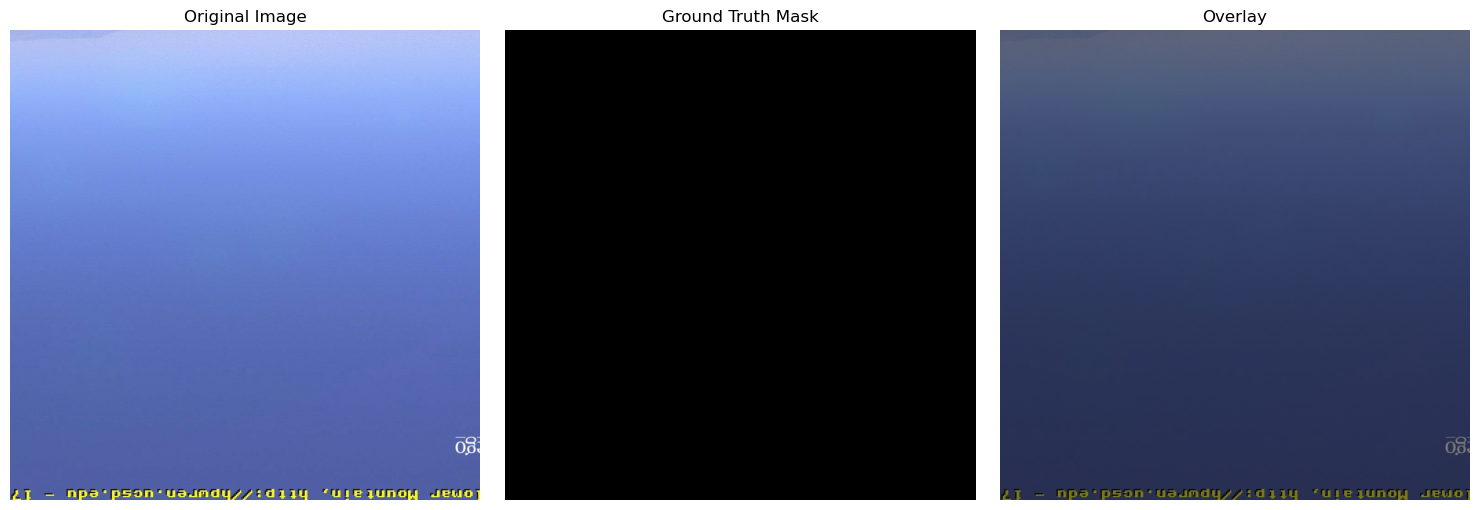

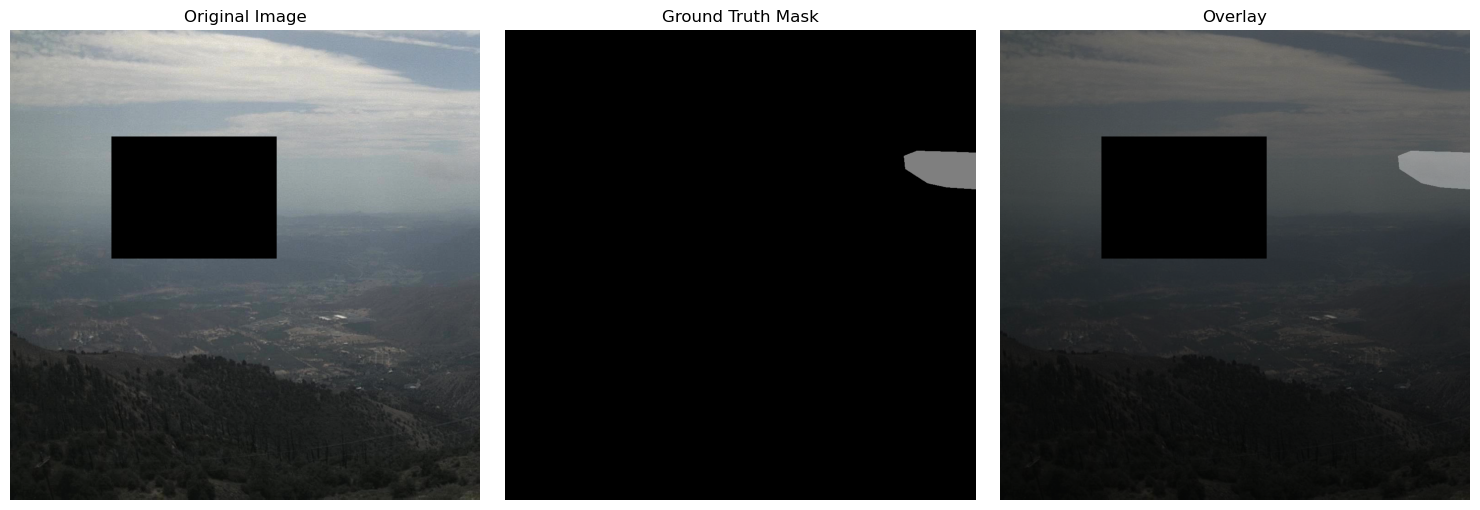

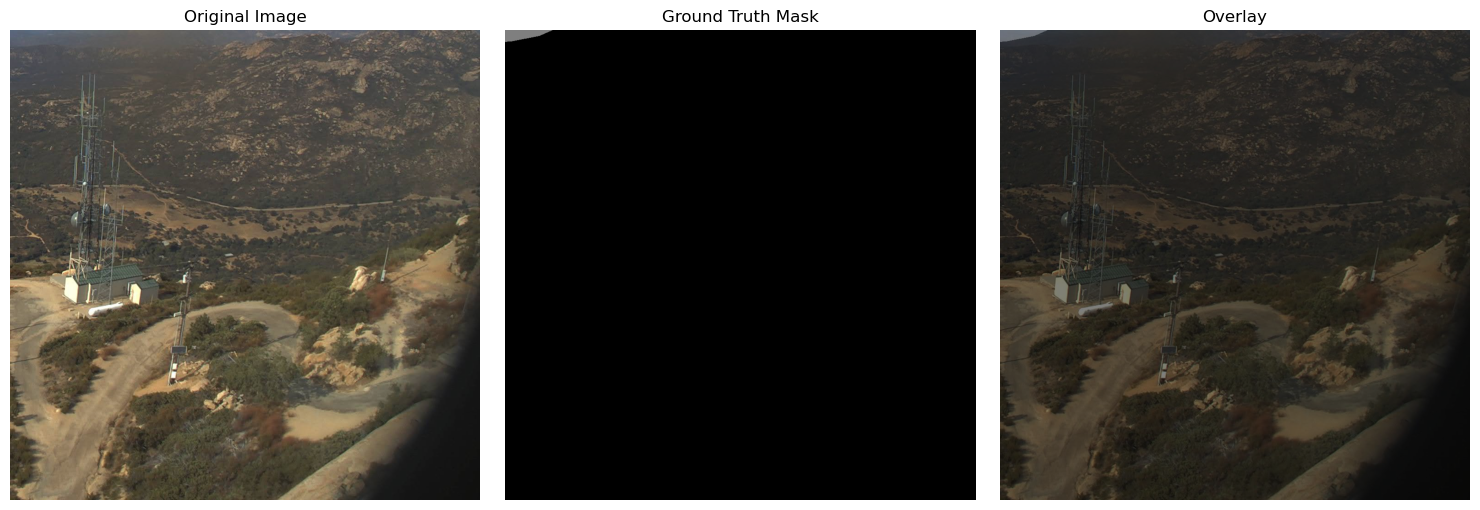

In [21]:
def visualize_sample(dataset, idx=0):
    sample = dataset[idx]

    image = sample['pixel_values'].numpy().transpose(1, 2, 0)
    mean = dataset.preprocessor.mean
    std = dataset.preprocessor.std
    image = std * image + mean
    image = np.clip(image, 0, 1)

    if getattr(dataset.preprocessor, 'use_rgcr', False):
        image_title = 'Model Input (R,G,Cr)'
    else:
        image_title = 'Original Image'

    mask = sample['labels'].numpy()
    color_mask = np.zeros((*mask.shape, 3))
    color_mask[mask == 0] = [0, 0, 0]
    color_mask[mask == 1] = [1, 0, 0]
    color_mask[mask == 2] = [0.5, 0.5, 0.5]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(image)
    axes[0].set_title(image_title)
    axes[0].axis('off')

    axes[1].imshow(color_mask)
    axes[1].set_title('Ground Truth Mask')
    axes[1].axis('off')

    axes[2].imshow(image)
    axes[2].imshow(color_mask, alpha=0.5)
    axes[2].set_title('Overlay')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

print('Training samples:')
for i in range(min(3, len(data_module.train_dataset))):
    visualize_sample(data_module.train_dataset, i)

## 10. Initialize Model and Trainer

In [22]:
model = PIDNetFinetuner(
    model_name=MODEL_NAME,
    num_classes=NUM_CLASSES,
    learning_rate=LEARNING_RATE,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    class_weights=CLASS_WEIGHTS,
    lovasz_weight=LOVASZ_WEIGHT,
    focal_weight=FOCAL_WEIGHT,
    dice_weight=DICE_WEIGHT,
    focal_gamma=FOCAL_GAMMA,
    pretrained_weights=PRETRAINED_WEIGHTS,
    use_aux_loss=USE_AUX_LOSS,
    aux_loss_weight=AUX_LOSS_WEIGHT
)

checkpoint_callback = ModelCheckpoint(
    dirpath='checkpoints',
    filename='pidnet-fire-smokeNEWDATASETRGBTiling-{epoch:02d}-{val_fire_smoke_iou:.3f}',
    save_top_k=3,
    monitor='val_fire_smoke_iou',
    mode='max'
)

early_stop_callback = EarlyStopping(
    monitor='val_fire_smoke_iou',
    patience=20,
    mode='max',
    verbose=True
)

logger = TensorBoardLogger('logs', name='pidnet_fire_smokeNEWDATASETRGBTiling')

trainer = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator='auto',
    devices=1,
    callbacks=[checkpoint_callback, early_stop_callback],
    logger=logger,
    log_every_n_steps=10,
    precision='16-mixed' if torch.cuda.is_available() else 32,
    benchmark=False,
    deterministic='warn'
)

print(f'Trainer initialized. Using device: {trainer.strategy.root_device}')
print('Trainer optimizations:')
print(f"  - Mixed precision: {'16-bit' if torch.cuda.is_available() else '32-bit'}")
print('  - cuDNN benchmark: False (for reproducibility)')
print('  - Deterministic: True (for reproducibility)')
print('Loss mix:')
print(f'  - Lovasz weight: {LOVASZ_WEIGHT}')
print(f'  - Focal weight: {FOCAL_WEIGHT}')
print(f'  - Dice weight: {DICE_WEIGHT}')


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Loaded pretrained weights from PIDNet/pretrained_models/imagenet/PIDNet_M_ImageNet.pth.tar
Missing keys: 126, Unexpected keys: 44
Trainer initialized. Using device: cuda:0
Trainer optimizations:
  - Mixed precision: 16-bit
  - cuDNN benchmark: False (for reproducibility)
  - Deterministic: True (for reproducibility)
Loss mix:
  - Lovasz weight: 0.33
  - Focal weight: 0.33
  - Dice weight: 0.34


In [12]:
#flush vram
torch.cuda.empty_cache()


In [13]:

# Recommended for Ampere+ GPUs (like RTX 4070)
torch.set_float32_matmul_precision('high')

/home/maks/miniconda3/envs/AIEnv/lib/python3.10/site-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)


## 11. Train the Model

In [40]:
trainer.fit(model, data_module)

/tmp/ipykernel_17789/333141834.py:77: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, min_height, min_width, fill_value, mask_fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=64, max_width=64, min_holes=1, min_height=8, min_width=8, fill_value=0, mask_fill_value=0, p=0.3),
/home/maks/miniconda3/envs/AIEnv/lib/python3.10/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /mnt/c/Users/PC/Documents/Researchfr/PIDNet/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/maks/miniconda3/envs/AIEnv/lib/python3.10/site-packages/pytorch_lightning/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name      | Type         | Params | Mode  | FLOPs
-----------------------------------------------------------
0 | model     | PIDNet   

Loaded splits and tiles from data_splits_and_tilingproper.json
Train samples (images): 13192
Val samples (images): 1649
Test samples (images): 1649
Effective train samples: 66339
Effective val   samples: 9300
Effective test  samples: 9200


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Confusion matrix saved: metrics/validation/confusion_matrix_epoch_best_epoch_0.png
Confusion matrix saved: metrics/validation/confusion_matrix_epoch_0.png


Training: |          | 0/? [00:00<?, ?it/s]

...

Confusion matrix saved: metrics/validation/confusion_matrix_epoch_best_epoch_22.png


Validation: |          | 0/? [00:00<?, ?it/s]


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

/home/maks/miniconda3/envs/AIEnv/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


### 11.1 Resume Training from Checkpoint (Optional)

If training is interrupted, resume with:

```python
import glob
checkpoints = sorted(glob.glob('checkpoints/*.ckpt'))
if checkpoints:
    latest_ckpt = checkpoints[-1]
    trainer.fit(model, data_module, ckpt_path=latest_ckpt)
```

In [14]:
import glob
import gc

# Bug #5 fix: sort by the IoU value embedded in the filename
# (pattern: ...-{epoch:02d}-{val_fire_smoke_iou:.3f}.ckpt)
def _ckpt_iou(path):
    try:
        return float(path.rsplit('-', 1)[-1].replace('.ckpt', ''))
    except ValueError:
        return 0.0

checkpoints = sorted(glob.glob('checkpoints/*.ckpt'), key=_ckpt_iou)
if checkpoints:
    latest_ckpt = checkpoints[-1]  # highest IoU checkpoint
    latest_ckpt= "/mnt/c/Users/PC/Documents/Researchfr/PIDNet/checkpoints/pidnet-fire-smokeNEWDATASETRGBTiling-epoch=23-val_fire_smoke_iou=0.723.ckpt"
    print(f'Resuming from: {latest_ckpt}')

    # Reduce stale memory pressure before resume in long-lived notebook sessions
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    trainer.fit(model, data_module, ckpt_path=latest_ckpt)
else:
    print('No checkpoints found. Run the training cell first.')

Resuming from: /mnt/c/Users/PC/Documents/Researchfr/PIDNet/checkpoints/pidnet-fire-smokeNEWDATASETRGCrAT4REAL2-epoch=23-val_fire_smoke_iou=0.723.ckpt


/tmp/ipykernel_1775/333141834.py:77: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, min_height, min_width, fill_value, mask_fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=64, max_width=64, min_holes=1, min_height=8, min_width=8, fill_value=0, mask_fill_value=0, p=0.3),
/home/maks/miniconda3/envs/AIEnv/lib/python3.10/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /mnt/c/Users/PC/Documents/Researchfr/PIDNet/checkpoints exists and is not empty.
Restoring states from the checkpoint path at /mnt/c/Users/PC/Documents/Researchfr/PIDNet/checkpoints/pidnet-fire-smokeNEWDATASETRGCrAT4REAL2-epoch=23-val_fire_smoke_iou=0.723.ckpt


Loaded splits and tiles from data_splits_and_tilingproper.json
Train samples (images): 13192
Val samples (images): 1649
Test samples (images): 1649
Effective train samples: 66339
Effective val   samples: 9300
Effective test  samples: 9200


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/maks/miniconda3/envs/AIEnv/lib/python3.10/site-packages/pytorch_lightning/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name      | Type         | Params | Mode  | FLOPs
-----------------------------------------------------------
0 | model     | PIDNet       | 28.5 M | train | 0    
1 | criterion | CombinedLoss | 0      | train | 0    
-----------------------------------------------------------
28.5 M    Trainable params
0         Non-trainable params
28.5 M    Total params
114.146   Total estimated model params size (MB)
253       Modules in train mode
0         Modules in eval mode
0         Total Flops
Restored all states from the checkpoint at /mnt/c/Users/PC/Documents/Researchfr/PIDNet/checkpoints/pidnet-fire-smokeNEWDATASETRGCrAT4REAL2-epoch=23-val_fire_smoke_iou=0.723.ckpt


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

/home/maks/miniconda3/envs/AIEnv/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


## 12. Evaluate on Test Set

In [23]:
# Replace with your chosen checkpoint path
CKPT_PATH = '/mnt/c/Users/PC/Documents/Researchfr/PIDNet/checkpoints/pidnet-fire-smokeNEWDATASETRGBTiling14jul-epoch=48-val_fire_smoke_iou=0.735.ckpt'
trainer.test(model, data_module, ckpt_path=CKPT_PATH)

/tmp/ipykernel_1798/1029807506.py:76: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, min_height, min_width, fill_value, mask_fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=64, max_width=64, min_holes=1, min_height=8, min_width=8, fill_value=0, mask_fill_value=0, p=0.3),
Restoring states from the checkpoint path at /mnt/c/Users/PC/Documents/Researchfr/PIDNet/checkpoints/pidnet-fire-smokeNEWDATASETRGBTiling14jul-epoch=48-val_fire_smoke_iou=0.735.ckpt


Loaded splits and tiles from data_splits_and_tilingproper.json
Train samples (images): 13192
Val samples (images): 1649
Test samples (images): 1649
Effective train samples: 66339
Effective val   samples: 9300
Effective test  samples: 9200


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at /mnt/c/Users/PC/Documents/Researchfr/PIDNet/checkpoints/pidnet-fire-smokeNEWDATASETRGBTiling14jul-epoch=48-val_fire_smoke_iou=0.735.ckpt


Testing: |          | 0/? [00:00<?, ?it/s]

Processed 1649 test images...

TEST SET RESULTS (Reconstructed Full Resolution)
BACKGROUND   - Precision: 0.9994, Recall: 0.9984, F1: 0.9989, Support: 9186136540
FIRE         - Precision: 0.6818, Recall: 0.9587, F1: 0.7969, Support: 318069
SMOKE        - Precision: 0.8470, Recall: 0.9382, F1: 0.8902, Support: 86196143

Test IoU (Reconstructed) -- mean: 0.8208, fire+smoke: 0.7323
Confusion matrix saved: metrics/test/confusion_matrix_epoch_reconstructed.png
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   test_f1_background       0.9989097714424133
      test_f1_fire          0.7968631982803345
      test_f1_smoke         0.8902328610420227
   test_fire_smoke_f1       0.8435479998588562
   test_fire_smoke_iou      0.7322506308555603
test_fire_smoke_pre

[{'test_precision_background': 0.9994219541549683,
  'test_recall_background': 0.9983981251716614,
  'test_f1_background': 0.9989097714424133,
  'test_precision_fire': 0.6817559599876404,
  'test_recall_fire': 0.9587353467941284,
  'test_f1_fire': 0.7968631982803345,
  'test_precision_smoke': 0.8469641208648682,
  'test_recall_smoke': 0.9381605982780457,
  'test_f1_smoke': 0.8902328610420227,
  'test_fire_smoke_precision': 0.7643600106239319,
  'test_fire_smoke_recall': 0.9484480023384094,
  'test_fire_smoke_f1': 0.8435479998588562,
  'test_iou_background': 0.9978219866752625,
  'test_iou_fire': 0.6623213291168213,
  'test_iou_smoke': 0.8021799325942993,
  'test_mean_iou': 0.8207743763923645,
  'test_fire_smoke_iou': 0.7322506308555603}]

In [12]:
# Save the BEST checkpoint model in native PyTorch format
import json
from pathlib import Path

best_ckpt_path = "/mnt/c/Users/PC/Documents/Researchfr/PIDNet/checkpoints/pidnet-fire-smokeNEWDATASETRGBTiling-epoch=43-val_fire_smoke_iou=0.766.ckpt"
if not best_ckpt_path:
    raise RuntimeError("No best checkpoint found. Train the model first (trainer.fit).")

print(f"Loading best checkpoint: {best_ckpt_path}")
best_model = PIDNetFinetuner.load_from_checkpoint(best_ckpt_path, map_location='cpu')

output_dir = Path("pidnetfr4real_model_best")
output_dir.mkdir(parents=True, exist_ok=True)

# Save model weights
weights_path = output_dir / "pytorch_model.bin"
torch.save(best_model.model.state_dict(), weights_path)

# Save minimal config needed to rebuild the architecture
export_config = {
    "model_name": MODEL_NAME,
    "num_classes": NUM_CLASSES,
    "class_names": CLASS_NAMES,
    "image_size": list(IMAGE_SIZE),
    "id2label": ID2LABEL,
    "label2id": LABEL2ID
}
config_path = output_dir / "config.json"
with open(config_path, "w") as f:
    json.dump(export_config, f, indent=2)

# Save the original Lightning checkpoint path for traceability
metadata_path = output_dir / "metadata.txt"
with open(metadata_path, "w") as f:
    f.write(f"best_checkpoint={best_ckpt_path}\n")

print(f"Best model weights saved to: {weights_path}")
print(f"Config saved to: {config_path}")
print("\nTo load the model later:")
print("from pathlib import Path")
print("import json, torch")
print("model_dir = Path('pidnet_fire_smoke_model_best')")
print("cfg = json.loads((model_dir / 'config.json').read_text())")
print("model = build_pidnet_model(cfg['model_name'], cfg['num_classes'])")
print("state_dict = torch.load(model_dir / 'pytorch_model.bin', map_location='cpu')")
print("model.load_state_dict(state_dict, strict=True)")
print("model.eval()")

Loading best checkpoint: /mnt/c/Users/PC/Documents/Researchfr/PIDNet/checkpoints/pidnet-fire-smokeNEWDATASETRGCrAT4REAL2-epoch=43-val_fire_smoke_iou=0.766.ckpt
Loaded pretrained weights from PIDNet/pretrained_models/imagenet/PIDNet_M_ImageNet.pth.tar
Missing keys: 126, Unexpected keys: 44
Best model weights saved to: pidnetfr4real_model_best/pytorch_model.bin
Config saved to: pidnetfr4real_model_best/config.json

To load the model later:
from pathlib import Path
import json, torch
model_dir = Path('pidnet_fire_smoke_model_best')
cfg = json.loads((model_dir / 'config.json').read_text())
model = build_pidnet_model(cfg['model_name'], cfg['num_classes'])
state_dict = torch.load(model_dir / 'pytorch_model.bin', map_location='cpu')
model.load_state_dict(state_dict, strict=True)
model.eval()
